# Question 1

To incorporate fission, would be similair to adding scattering in the source iteration. Specifically, when updating the source for the next iteration, the following term would be added to the source term:

$$
Q_{f,g}^{l} = \chi_g \nu_g \sigma_{f,g} \phi_g^{l-1}
$$

# Question 3

Method: 	Diamond Difference
Converged in 4334 iterations
Spectral Radius:
	Final: 	 9.97091e-01
	Average: 9.97145e-01
	Max: 	 9.99000e-01

Method: 	Step Characteristics
Converged in 4328 iterations
Spectral Radius:
	Final: 	 9.97086e-01
	Average: 9.97141e-01
	Max: 	 9.99000e-01

Method: 	Diamond Difference - DSA
Converged in 10 iterations
Spectral Radius:
	Final: 	 2.02938e-01
	Average: 1.61289e-01
	Max: 	 2.02938e-01

Method: 	Step Characteristics - DSA
Converged in 10 iterations
Spectral Radius:
	Final: 	 2.02112e-01
	Average: 1.60783e-01
	Max: 	 2.02112e-01



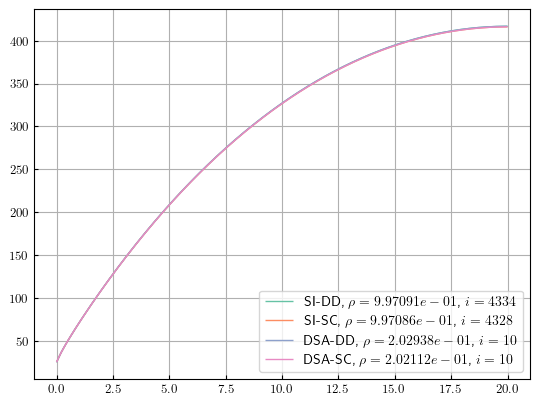

In [1]:
import q3

By far the most noticeable result is the massive decrease in number of iterations between DSA and non-DSA runs. the spectral radius is significantly lower for the DSA case than for the non-DSA case.

# Question 4

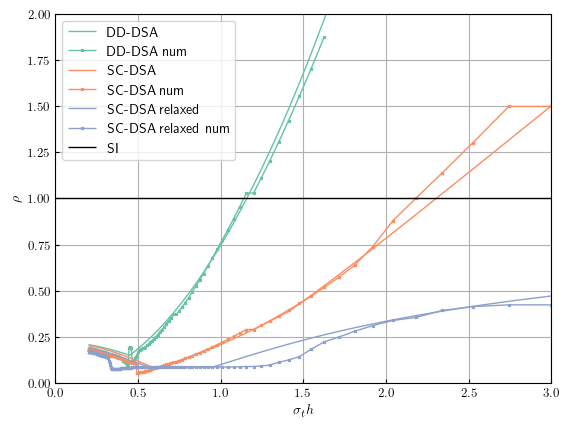

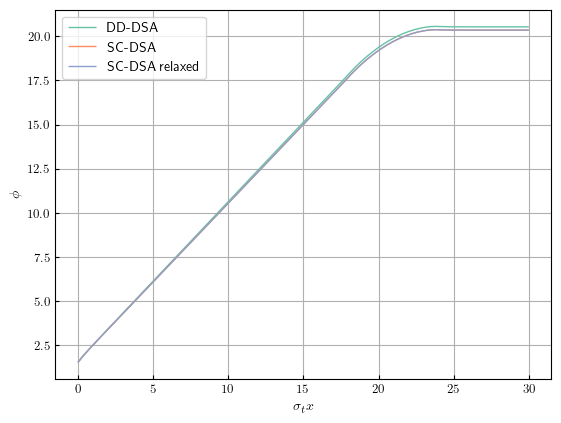

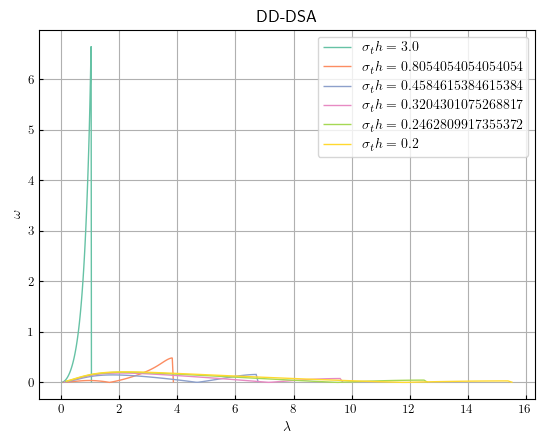

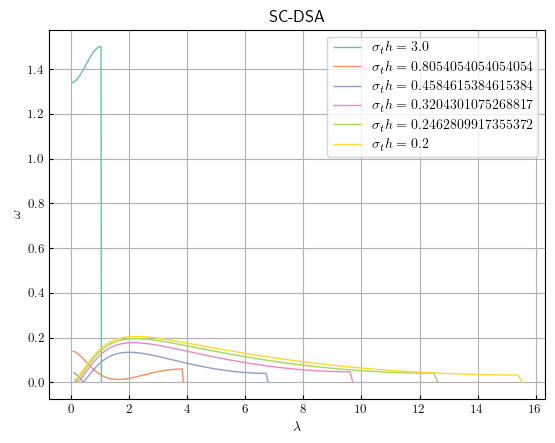

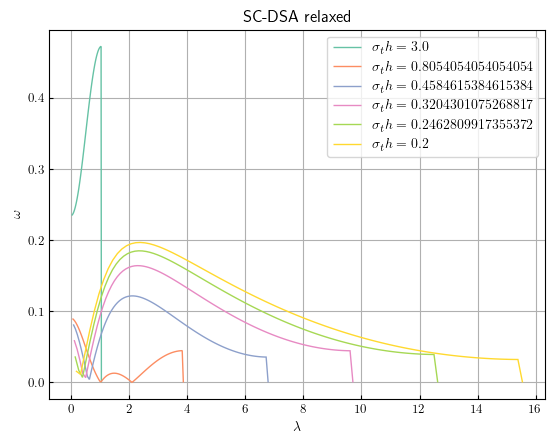

In [2]:
import q4

All methods experience a minimum spectral radius at around $\sigma_th=0.5$, after which further decrease of the grid spacing results in an increase in the spectral radius and thus convergence. For all methods, the numerical results are relatively close to the corresponding analytical curve, though the numerical reaches a lower minimum than the theoretical for each. Within the curves for the numerical results, specifically for the diamond difference case, some values are missing, and this is due to `nan` spectral radii. Additionally, for relatively high $sigma_t h$ (greater than 1.5), the methods begin to diverge. This is particularly visible with diamond difference, however one step of step characteristics also failed to converge. On the contrary though, relaxed DSA for step characteristics converged unconditionally, and quickly. 

In [3]:
display(q4.table.style.hide())

Sigma_t h,DD-DSA Analytical,DD-DSA Numerical,SC-DSA Analytical,SC-DSA Numerical,SC-DSA relaxed Analytical,SC-DSA relaxed Numerical
3.000000,6.647745,nan,1.501676,1.497853,0.472342,0.423950
1.500000,1.678559,1.553024,0.445054,0.431520,0.233306,0.143718
1.000000,0.747459,0.725923,0.210009,0.208612,0.100758,0.087355
0.750000,0.420730,0.391971,0.122864,0.122104,0.090154,0.089476
0.600000,0.269352,0.241441,0.080292,0.079818,0.089237,0.089547
0.500000,0.187082,0.154318,0.119606,0.055257,0.108369,0.086778
0.428571,0.157256,0.107597,0.144776,0.124655,0.131091,0.082415
0.375000,0.172097,0.146304,0.161891,0.141655,0.147733,0.078728
0.333333,0.182597,0.156662,0.174065,0.151379,0.160339,0.097768
0.300000,0.190265,0.167322,0.183015,0.158211,0.170086,0.146104


# Question 4: Fourier Analysis

## Finding $a_n$
To begin, we start with the general, discretized form of the SN transport equation:

$$
\frac{\mu_n}{h}\left(\psi_{n, j+1/2}^{l-1/2} - \psi_{n, j-1/2}^{l-1/2}\right) + \sigma_t \psi_{n, j}^{l-1/2} = \frac{1}{2}\sigma_s\phi_{j}^{l-1}
$$
and 
$$
\psi_{n, j}^{l-1/2} = \frac{1 - \alpha_n}{2}\psi_{n, j-1/2}^{l-1/2} + \frac{1 + \alpha_n}{2} \psi_{n, j+1/2}^{l-1/2}
$$

Then, substituting in the following fourier ansatz:
$$
\phi_{j}^l = \omega^le^{i\sigma_t\lambda x_j}\\
\psi_{n, j}^{l-1/2} =  \omega^{l-1}a_ne^{i\sigma_t\lambda x_j}\\
\psi_{n, j+1/2}^{l-1/2} = \omega^{l-1}b_ne^{i\sigma_t\lambda x_{j+1/2}}=\omega^{l-1}b_ne^{i\sigma_t\lambda (x_j + h/2)}\\
\psi_{n, j-1/2}^{l-1/2} = \omega^{l-1}b_ne^{i\sigma_t\lambda x_{j-1/2}}=\omega^{l-1}b_ne^{i\sigma_t\lambda (x_j - h/2)}\\
$$

we obtain the following equations (after dividing out the common $e^{i\sigma_t\lambda x_j}$ term):

$$
\frac{\mu_n b_n \omega^{l-1}}{h}\left(e^{i\sigma_t\lambda h/2} - e^{-i\sigma_t\lambda h/2}\right) + \sigma_t \omega^{l-1}a_n = \frac{1}{2}\sigma_s\omega^{l-1}\\
a_n = b_n\left(\frac{1 + \alpha_n}{2}e^{i\sigma_t\lambda h/2} - \frac{1 - \alpha_n}{2}e^{-i\sigma_t\lambda h/2}\right)
$$

which, substituting in $\tau_n=\frac{\sigma_t h \lambda}{2}$, simplifies to
$$
\frac{2i\mu_n b_n}{h}\sin(\tau) + \sigma_t a_n = \frac{1}{2}\sigma_s\\
a_n = b_n\left(\cos(\tau) + i\alpha\sin(\tau)\right)
$$

rearranging and solving for $a_n$, we find (dividing through by $\cos\tau$ and setting $\tan\tau=\Lambda$):
$$
a_n = \frac{c}{2}\frac{\cos(\tau) + i\alpha\sin(\tau)}{\cos(\tau) + i\sin(\tau)(\alpha + \frac{2\mu_n}{\sigma_t h})}\\
= \frac{c}{2}\frac{1 + i\alpha\tan(\tau)}{1 + i\tan(\tau)(\alpha + \frac{2\mu_n}{\sigma_t h})}\\
= \frac{c}{2}\frac{1 + i\alpha\Lambda}{1 + i\Lambda(\alpha + \frac{2\mu_n}{\sigma_t h})}\\
$$

## Finding $A$
Then, moving onto the next step, finding the mid phi term, $\phi^{l-1/2}_j$:
$$
\phi^{l-1/2}_j = \sum_n^N w_n\psi_{n, j}^{l-1/2}
$$

And, subbing in the following (and previously defined fourier ansatz):
$$
\phi^{l-1/2}_j = \omega^{l - 1}Ae^{i\sigma_t\lambda x_j}
$$
we can then get (with lots of complex conjugates and rearranging from mathematica):
$$
A = \sum_n^N w_n a_n\\
A = c\sum_{\mu_n>0}w_n \frac{1 + \alpha\left(\alpha + \frac{2\mu_n}{\sigma_t h}\right)\Lambda^2}{1 + \left(\alpha + \frac{2\mu_n}{\sigma_t h}\right)^2\Lambda^2}
$$

## Finding $\gamma$
Next, we move onto the diffusion equation to find the correction term:
$$
\frac{-1}{3\sigma_{tr}h}\left(F^l_{j+1} - F^l_j\right) + \frac{1}{3\sigma_{tr}h}\left(F^l_{j} - F^l_{j-1}\right) + \sigma_a h F^l_j = \sigma_s h\left[\phi_j^{l-1/2} - \phi_j^{l-1}\right]
$$

And again, defining the following fourier ansatz:

$$
F_{j}^{l} = \omega^{l-1}\gamma e^{i\sigma_t\lambda x_{j}}\\
F_{j-1}^{l} = \omega^{l-1}\gamma e^{i\sigma_t\lambda x_{j-1}} = \omega^{l-1}\gamma e^{i\sigma_t\lambda (x_j - h)}\\
F_{j+1}^{l} = \omega^{l-1}\gamma e^{i\sigma_t\lambda (x_j + h)}\\
$$

and subbing back into the diffusion equation, dividing through by common terms for simplicity:
$$
\frac{-1}{3\sigma_{tr}h}\gamma\left(e^{i\sigma_t\lambda h} - 1\right) + \frac{1}{3\sigma_{tr}h}\gamma\left(1 - e^{-i\sigma_t\lambda h}\right) + \sigma_a h \gamma = \sigma_s h\left[A - 1\right]\\
\frac{\gamma}{3\sigma_{tr}h}\left(2 - 2\cos(2\tau)\right)+ \sigma_a h \gamma = \sigma_s h\left[A - 1\right]\\
\frac{4\gamma}{3\sigma_{tr}h}\sin^2(\tau) + \sigma_a h \gamma = \sigma_s h\left[A - 1\right]\\
\gamma = \frac{\sigma_s h\left[A - 1\right]}{\frac{4}{3\sigma_{tr}h}\sin^2(\tau) + (\sigma_t - \sigma_s) h }\\
\gamma = c\frac{A - 1}{\frac{1}{3}\left(\frac{2}{\sigma_t h}\sin(\tau)\right)^2 + 1 - c}
$$

## Finding $\omega$ and $\beta$
Finally, from our update condition:
$$
\phi^{l} = \phi^{l-1/2} + (1-\beta)F^l\\
\omega^{l} = A\omega^{l-1} + (1-\beta)\gamma\omega^{l-1}\\
\omega = A + (1-\beta)\gamma\\
$$

and, we know that to find the optimal beta we impose:

$$
\omega(0) = \omega(\pi/2)\\
\beta = 1 + \frac{A(0) + A(\pi/2)}{\gamma(0) + \gamma(\pi/2)}
$$

And thus take the limit of $A$ and $\gamma$ as $\tau$ approaches $0$ and $\pi/2$:

$$
A(0) = c\sum_{\mu_n>0}w_n \frac{1 + \alpha\left(\alpha + \frac{2\mu_n}{\sigma_t h}\right)\Lambda^2}{1 + \left(\alpha + \frac{2\mu_n}{\sigma_t h}\right)^2\Lambda^2}\\
A(0) = c\sum_{\mu_n>0}w_n \frac{1 + \alpha\left(\alpha + \frac{2\mu_n}{\sigma_t h}\right)0}{1 + \left(\alpha + \frac{2\mu_n}{\sigma_t h}\right)^20}\\
A(0) = c
$$
then
$$
A(\pi/2) = c\sum_{\mu_n>0}w_n \frac{1 + \alpha\left(\alpha + \frac{2\mu_n}{\sigma_t h}\right)\Lambda^2}{1 + \left(\alpha + \frac{2\mu_n}{\sigma_t h}\right)^2\Lambda^2}\\
A(\pi/2) = c\sum_{\mu_n>0}w_n \frac{\alpha\left(\alpha + \frac{2\mu_n}{\sigma_t h}\right)}{\left(\alpha + \frac{2\mu_n}{\sigma_t h}\right)^2}\\
A(\pi/2) = c\sum_{\mu_n>0}w_n \frac{\alpha}{\left(\alpha + \frac{2\mu_n}{\sigma_t h}\right)}\\
$$

and 
$$
\gamma(0) = c\frac{A(0) - 1}{\frac{1}{3}\left(\frac{2}{\sigma_t h}\sin(0)\right)^2 + 1 - c}\\
\gamma(0) = c\frac{c - 1}{1 - c}\\
\gamma(0) = -c
$$
then
$$
\gamma(\pi/2) = c\frac{A(\pi/2) - 1}{\frac{1}{3}\left(\frac{2}{\sigma_t h}\sin(\pi/2)\right)^2 + 1 - c}\\
\gamma(\pi/2) = c\frac{A(\pi/2) - 1}{\frac{4}{3\sigma_t^2h^2} + 1 - c}\\
$$

and for simplicity, these were not simplified further but instead implemented into the code as is.

## Conclusion
For DD-DSA, $\alpha_n$ is 0 and so the terms can be simplified further. For SC-DSA, beta is assumed to be 0, so the terms also simplify further (particularly $\omega$). For relaxed SC-DSA, no terms are simplified.